In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set display options for easier dataframe inspection
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

file_path = 'kyc_industry_dataset.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Basic inspection
print("--- Dataset Shape ---")
print(df.shape, "\n")

print("--- Data Types & Missing Values ---")
print(df.info(), "\n")

print("--- First 5 Rows ---")
display(df.head())

--- Dataset Shape ---
(1000, 15) 

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_id            1000 non-null   object
 1   age                    1000 non-null   int64 
 2   country_risk           1000 non-null   object
 3   occupation             1000 non-null   object
 4   annual_income          1000 non-null   int64 
 5   account_type           1000 non-null   object
 6   document_status        1000 non-null   object
 7   address_verified       1000 non-null   object
 8   pep_flag               1000 non-null   object
 9   sanctions_flag         1000 non-null   object
 10  adverse_media_flag     1000 non-null   object
 11  customer_tenure_years  1000 non-null   int64 
 12  digital_risk_score     1000 non-null   int64 
 13  fraud_history_flag     1000 non-null   int64 
 14  mo

,customer_id,age,country_risk,occupation,annual_income,account_type,document_status,address_verified,pep_flag,sanctions_flag,adverse_media_flag,customer_tenure_years,digital_risk_score,fraud_history_flag,monthly_txn_count
0,C5000,45,High,Salaried,2687167,Current,Complete,Yes,No,No,No,1,31,1,442
1,C5001,62,Low,Self Employed,3572495,Corporate,Complete,Yes,No,No,No,9,22,0,401
2,C5002,46,High,Salaried,4553633,Savings,Partial,Yes,No,No,No,0,47,0,270
3,C5003,23,High,Business,2982877,Savings,Partial,No,No,No,No,3,41,0,267
4,C5004,59,Medium,Salaried,1719924,Current,Complete,No,No,No,No,15,72,0,289


In [4]:
# Grouping columns by their preprocessing requirements

# 1. Identifier (Exclude from modelling)
id_col = 'customer_id'

# 2. Binary Flags (Need to be enforced as integers 0/1)
binary_flags = [
    'address_verified',
    'pep_flag',
    'sanctions_flag',
    'adverse_media_flag',
    'fraud_history_flag'
]

# 3. Categorical Features (Need One-Hot Encoding)
categorical_cols = [
    'country_risk',
    'occupation',
    'account_type',
    'document_status'
]

# 4. Numerical Features (Need Scaling)
numerical_cols = [
    'age',
    'annual_income',
    'customer_tenure_years',
    'digital_risk_score',
    'monthly_txn_count'
]

In [6]:
# Create a copy to preserve the original dataframe
df_clean = df.copy()

# Dictionary to map common text booleans to 1 and 0
bool_mapping = {
    'Yes': 1, 'No': 0,
    'yes': 1, 'no': 0,
    'Y': 1, 'N': 0,
    'True': 1, 'False': 0,
    '1': 1, '0': 0
}

for col in binary_flags:
    # 1. Replace string values with numbers if they exist in the mapping
    # (We use regex=False to ensure exact matching)
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].replace(bool_mapping)

    # 2. Convert to numeric (coercing any weird leftover strings to NaN)
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # 3. Fill missing values with 0 and finally cast to integer
    df_clean[col] = df_clean[col].fillna(0).astype(int)

print("Binary flags cleaned and cast to integers.")
print(df_clean[binary_flags].dtypes)
display(df_clean[binary_flags].head())

Binary flags cleaned and cast to integers.
address_verified      int64
pep_flag              int64
sanctions_flag        int64
adverse_media_flag    int64
fraud_history_flag    int64
dtype: object


,address_verified,pep_flag,sanctions_flag,adverse_media_flag,fraud_history_flag
0,1,0,0,0,1
1,1,0,0,0,0
2,1,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [9]:
# Numerical Pipeline: Impute missing values with the median, then scale
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Impute missing with the most frequent value, then One-Hot Encode
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ],
    remainder='drop' # Drop remaining columns here, we'll manually append them next
)

In [10]:
# Fit and transform the data
transformed_data = preprocessor.fit_transform(df_clean)

# Get new feature names for the One-Hot Encoded columns
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = numerical_cols + list(ohe_feature_names) + [id_col] + binary_flags

# Reconstruct the DataFrame
# Manually append the customer_id and binary flags to the transformed array
passthrough_data = df_clean[[id_col] + binary_flags].values
final_data = np.hstack((transformed_data, passthrough_data))

df_preprocessed = pd.DataFrame(final_data, columns=all_feature_names)

# Ensure correct data types post-reconstruction
for col in numerical_cols:
    df_preprocessed[col] = df_preprocessed[col].astype(float)

for col in binary_flags:
    df_preprocessed[col] = df_preprocessed[col].astype(int)

print("Preprocessing complete!")
display(df_preprocessed.head())

Preprocessing complete!


,age,annual_income,customer_tenure_years,digital_risk_score,monthly_txn_count,country_risk_High,country_risk_Low,country_risk_Medium,occupation_Business,occupation_Cash Business,occupation_Salaried,occupation_Self Employed,occupation_Student,account_type_Corporate,account_type_Current,account_type_NRI,account_type_Savings,document_status_Complete,document_status_Missing,document_status_Partial,customer_id,address_verified,pep_flag,sanctions_flag,adverse_media_flag,fraud_history_flag
0,-0.146946,0.083158,-1.395135,-0.656593,1.319590,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,C5000,1,0,0,0,1
1,0.893487,0.723373,0.353428,-0.964820,1.032916,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,C5001,1,0,0,0,0
2,-0.085744,1.432871,-1.613705,-0.108633,0.116956,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,C5002,1,0,0,0,0
3,-1.493389,0.296997,-0.957994,-0.314118,0.095980,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,C5003,0,0,0,0,0
4,0.709882,-0.616292,1.664851,0.747554,0.249805,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,C5004,0,0,0,0,0


In [11]:
# Create the composite risk indicators
print("Engineering new features...")

# 1. Compliance Risk Composite (Sum of PEP, Sanctions, and Adverse Media)
df_clean['compliance_risk_composite'] = (
    df_clean['pep_flag'] +
    df_clean['sanctions_flag'] +
    df_clean['adverse_media_flag']
)

# 2. Document Completeness Score
# Assuming 'Complete' gives 1 point, plus 1 point if address is verified
is_doc_complete = (df_clean['document_status'] == 'Complete').astype(int)
df_clean['document_completeness_score'] = is_doc_complete + df_clean['address_verified']

# 3. Behavioural Signal: Txn to Income Ratio
# Adding a small epsilon (1) to annual_income to prevent division-by-zero errors
df_clean['txn_to_income_ratio'] = df_clean['monthly_txn_count'] / (df_clean['annual_income'] + 1)

# 4. New Customer Flag (Tenure == 0)
df_clean['is_new_customer'] = (df_clean['customer_tenure_years'] == 0).astype(int)

# 5. Age Binning (Under 20, 20-60, Over 60)
# We use pd.cut to group the numerical age into categorical bins
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 20, 60, 150], # 0-20, 20-60, 60+
    labels=['Under 20', '20-60', 'Over 60']
)

print("Feature engineering complete!")
# Display the newly engineered columns
new_cols = ['compliance_risk_composite', 'document_completeness_score',
            'txn_to_income_ratio', 'is_new_customer', 'age_group']
display(df_clean[['customer_id'] + new_cols].head())

Engineering new features...
Feature engineering complete!


,customer_id,compliance_risk_composite,document_completeness_score,txn_to_income_ratio,is_new_customer,age_group
0,C5000,0,2,0.000164,0,20-60
1,C5001,0,2,0.000112,0,Over 60
2,C5002,0,1,0.000059,1,20-60
3,C5003,0,0,0.000090,0,20-60
4,C5004,0,1,0.000168,0,20-60


In [12]:
# Update our feature groups with the new engineered columns

# Add 'age_group' to categorical
updated_categorical_cols = categorical_cols + ['age_group']

# Add our continuous/ratio features to numerical
updated_numerical_cols = numerical_cols + ['txn_to_income_ratio']

# Add our new flags/counters to the passthrough list
updated_binary_flags = binary_flags + ['is_new_customer', 'compliance_risk_composite', 'document_completeness_score']

# Re-define pipelines with the updated column lists
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, updated_numerical_cols),
        ('cat', cat_pipeline, updated_categorical_cols)
    ],
    remainder='drop'
)

In [13]:
# Fit and transform the newly engineered data
transformed_data = preprocessor.fit_transform(df_clean)

# Get feature names for One-Hot Encoded columns (now includes age_group)
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(updated_categorical_cols)

# Combine all feature names
all_feature_names = updated_numerical_cols + list(ohe_feature_names) + [id_col] + updated_binary_flags

# Extract the un-transformed columns (ID + all flags)
passthrough_data = df_clean[[id_col] + updated_binary_flags].values

# Reconstruct the final numpy array and convert to DataFrame
final_data = np.hstack((transformed_data, passthrough_data))
df_engineered = pd.DataFrame(final_data, columns=all_feature_names)

# Enforce numerical types
for col in updated_numerical_cols:
    df_engineered[col] = df_engineered[col].astype(float)

for col in updated_binary_flags:
    df_engineered[col] = df_engineered[col].astype(int)

print(f"Final shape of the engineered dataset: {df_engineered.shape}")
display(df_engineered.head())

Final shape of the engineered dataset: (1000, 33)


,age,annual_income,customer_tenure_years,digital_risk_score,monthly_txn_count,txn_to_income_ratio,country_risk_High,country_risk_Low,country_risk_Medium,occupation_Business,occupation_Cash Business,occupation_Salaried,occupation_Self Employed,occupation_Student,account_type_Corporate,account_type_Current,account_type_NRI,account_type_Savings,document_status_Complete,document_status_Missing,document_status_Partial,age_group_20-60,age_group_Over 60,age_group_Under 20,customer_id,address_verified,pep_flag,sanctions_flag,adverse_media_flag,fraud_history_flag,is_new_customer,compliance_risk_composite,document_completeness_score
0,-0.146946,0.083158,-1.395135,-0.656593,1.319590,-0.025705,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,C5000,1,0,0,0,1,0,0,2
1,0.893487,0.723373,0.353428,-0.964820,1.032916,-0.261008,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,C5001,1,0,0,0,0,0,0,2
2,-0.085744,1.432871,-1.613705,-0.108633,0.116956,-0.499527,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,C5002,1,0,0,0,0,1,0,1
3,-1.493389,0.296997,-0.957994,-0.314118,0.095980,-0.363417,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,C5003,0,0,0,0,0,0,0,0
4,0.709882,-0.616292,1.664851,0.747554,0.249805,-0.009736,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,C5004,0,0,0,0,0,0,0,1


In [14]:
# Create a copy to store our risk calculations
df_risk = df_clean.copy()

# Initialize base score
df_risk['risk_score'] = 0

# 1. Critical Flags (Heavy Weights)
df_risk['risk_score'] += df_risk['sanctions_flag'] * 50
df_risk['risk_score'] += df_risk['fraud_history_flag'] * 30

# 2. High Flags
df_risk['risk_score'] += df_risk['pep_flag'] * 15
df_risk['risk_score'] += df_risk['adverse_media_flag'] * 15
df_risk['risk_score'] += df_risk['document_status'].apply(lambda x: 15 if x in ['Expired', 'Incomplete'] else 0)

# 3. Medium Flags
df_risk['risk_score'] += df_risk['country_risk'].apply(lambda x: 15 if x == 'HIGH' else (5 if x == 'MEDIUM' else 0))
df_risk['risk_score'] += df_risk['address_verified'].apply(lambda x: 10 if x == 0 else 0)
df_risk['risk_score'] += df_risk['digital_risk_score'] * 0.15 # Scale 0-100 to max 15 points

# 4. Low Flags (Behavioural & Profile)
df_risk['risk_score'] += df_risk['is_new_customer'] * 5
# High transaction to income ratio gets penalized (assuming normal ratio is < 0.1)
df_risk['risk_score'] += df_risk['txn_to_income_ratio'].apply(lambda x: 5 if x > 0.1 else 0)

# Cap the score at 100
df_risk['risk_score'] = df_risk['risk_score'].clip(upper=100)

# Define Risk Tiers based on score
def assign_tier(score):
    if score >= 65:
        return 'HIGH'
    elif score >= 35:
        return 'MEDIUM'
    else:
        return 'LOW'

df_risk['risk_tier'] = df_risk['risk_score'].apply(assign_tier)

print("Risk Score Calculation Complete.")
print(df_risk['risk_tier'].value_counts())

Risk Score Calculation Complete.
risk_tier
LOW       565
MEDIUM    409
HIGH       26
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Prepare feature matrix (X) and target vector (y)
# We drop customer_id because it's just an identifier
X = df_engineered.drop(columns=['customer_id'])
y = df_risk['risk_tier']

# Map target to integers for the model (0: LOW, 1: MEDIUM, 2: HIGH)
tier_mapping = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
y_encoded = y.map(tier_mapping)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
target_names = ['LOW', 'MEDIUM', 'HIGH']

print("--- Model Evaluation ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# Predict on the ENTIRE dataset to generate the final CSV
all_predictions = rf_model.predict(X)
df_risk['predicted_tier_encoded'] = all_predictions

# Reverse map the predictions back to text labels
reverse_mapping = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
df_risk['predicted_risk_tier'] = df_risk['predicted_tier_encoded'].map(reverse_mapping)

--- Model Evaluation ---
              precision    recall  f1-score   support

         LOW       0.98      1.00      0.99       113
      MEDIUM       0.95      0.98      0.96        82
        HIGH       1.00      0.20      0.33         5

    accuracy                           0.97       200
   macro avg       0.98      0.73      0.76       200
weighted avg       0.97      0.97      0.96       200



In [16]:
def recommend_decision(tier):
    if tier == 'LOW':
        return 'APPROVE'
    elif tier == 'MEDIUM':
        return 'MANUAL_REVIEW'
    elif tier == 'HIGH':
        return 'REJECT / EDD'

df_risk['decision'] = df_risk['predicted_risk_tier'].apply(recommend_decision)
print("Decisions generated successfully.")
display(df_risk[['risk_score', 'predicted_risk_tier', 'decision']].head())

Decisions generated successfully.


,risk_score,predicted_risk_tier,decision
0,34.65,LOW,APPROVE
1,3.30,LOW,APPROVE
2,12.05,LOW,APPROVE
3,16.15,LOW,APPROVE
4,20.80,LOW,APPROVE


In [18]:
import shap
import numpy as np

print("Calculating SHAP values (This might take a minute depending on dataset size)...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

top_risk_factors = []
feature_names = X.columns.tolist()

# Check if shap_values is a list (older versions) or a 3D array (newer versions)
is_list = isinstance(shap_values, list)

for i in range(len(X)):
    pred_class = df_risk['predicted_tier_encoded'].iloc[i]

    if pred_class == 0:  # If LOW risk, no negative flags needed
        top_risk_factors.append("None (Low Risk)")
    else:
        # Extract the correct SHAP array for this specific customer and predicted class
        if is_list:
            # Old SHAP version behavior: list of arrays
            instance_shap = shap_values[pred_class][i]
        else:
            # New SHAP version behavior: 3D numpy array (samples, features, classes)
            instance_shap = shap_values[i, :, pred_class]

        # Get indices of the highest positive SHAP values (factors pushing them into Medium/High risk)
        top_indices = np.argsort(instance_shap)[-3:][::-1]

        # Keep only the features that actually had a positive contribution (> 0)
        factors = [feature_names[idx] for idx in top_indices if instance_shap[idx] > 0]

        if not factors:
            factors = ["Complex feature interactions"]

        top_risk_factors.append(", ".join(factors))

df_risk['top_risk_factors'] = top_risk_factors

print("Explainability extraction complete.")
display(df_risk[df_risk['predicted_risk_tier'] != 'LOW'][['predicted_risk_tier', 'top_risk_factors']].head())

Calculating SHAP values (This might take a minute depending on dataset size)...
Explainability extraction complete.


,predicted_risk_tier,top_risk_factors
6,MEDIUM,"fraud_history_flag, digital_risk_score, sancti..."
7,MEDIUM,"fraud_history_flag, digital_risk_score, sancti..."
8,MEDIUM,"fraud_history_flag, address_verified, complian..."
9,MEDIUM,"fraud_history_flag, digital_risk_score, compli..."
13,MEDIUM,"fraud_history_flag, address_verified, complian..."


In [19]:
# Construct the final DataFrame with only the requested columns
final_output = pd.DataFrame({
    'customer_id': df_risk['customer_id'],
    'risk_score': df_risk['risk_score'],
    'risk_tier': df_risk['predicted_risk_tier'],
    'decision': df_risk['decision'],
    'top_risk_factors': df_risk['top_risk_factors']
})

# Save to CSV
output_filename = 'kyc_output.csv'
final_output.to_csv(output_filename, index=False)

print(f"✅ Success! Pipeline completed and exported to '{output_filename}'.")

# Display a preview of the final deliverable
display(final_output.head(10))

✅ Success! Pipeline completed and exported to 'kyc_output.csv'.


,customer_id,risk_score,risk_tier,decision,top_risk_factors
0,C5000,34.65,LOW,APPROVE,None (Low Risk)
1,C5001,3.30,LOW,APPROVE,None (Low Risk)
2,C5002,12.05,LOW,APPROVE,None (Low Risk)
3,C5003,16.15,LOW,APPROVE,None (Low Risk)
4,C5004,20.80,LOW,APPROVE,None (Low Risk)
5,C5005,7.35,LOW,APPROVE,None (Low Risk)
6,C5006,39.90,MEDIUM,MANUAL_REVIEW,"fraud_history_flag, digital_risk_score, sancti..."
7,C5007,41.10,MEDIUM,MANUAL_REVIEW,"fraud_history_flag, digital_risk_score, sancti..."
8,C5008,43.90,MEDIUM,MANUAL_REVIEW,"fraud_history_flag, address_verified, complian..."
9,C5009,39.75,MEDIUM,MANUAL_REVIEW,"fraud_history_flag, digital_risk_score, compli..."


Evaluating Model Performance and Efficiency...

▶ Model Accuracy on Test Set: 97.00%

--- Cross-Validation (5-Fold) ---
CV Accuracy Scores: [0.965 0.96  0.95  0.975 0.955]
Mean CV Accuracy: 96.10% (+/- 1.72%)

--- Model Efficiency ---
Time to predict 200 samples: 0.020279 seconds
Average time per prediction: 0.1014 milliseconds

--- Classification Report ---
              precision    recall  f1-score   support

         LOW       0.98      1.00      0.99       113
      MEDIUM       0.95      0.98      0.96        82
        HIGH       1.00      0.20      0.33         5

    accuracy                           0.97       200
   macro avg       0.98      0.73      0.76       200
weighted avg       0.97      0.97      0.96       200



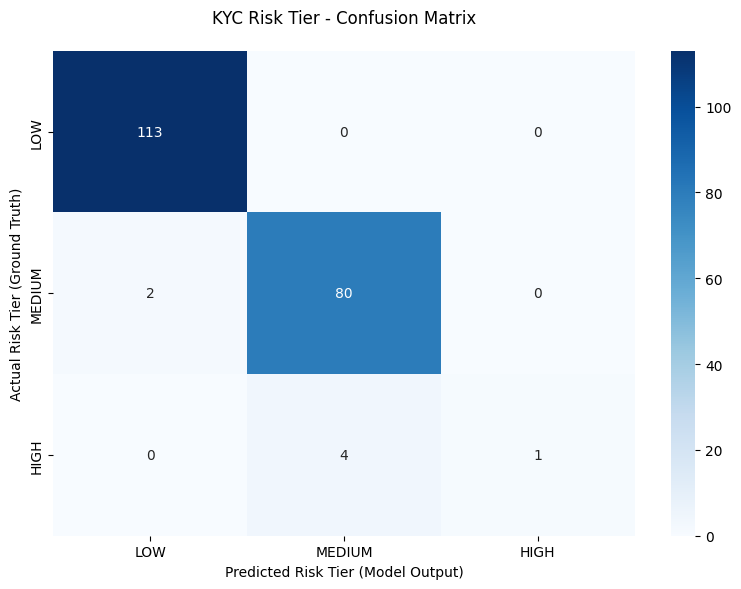

In [20]:
import time
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Evaluating Model Performance and Efficiency...\n")

# 1. Overall Accuracy
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"▶ Model Accuracy on Test Set: {accuracy * 100:.2f}%\n")

# 2. Cross-Validation (Testing Robustness)
# This trains the model 5 separate times on different cuts of the data
# to ensure it's not just getting lucky with the train_test_split.
print("--- Cross-Validation (5-Fold) ---")
cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5, scoring='accuracy')
print(f"CV Accuracy Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 200:.2f}%)\n")

# 3. Model Efficiency (Inference Time)
# Testing how fast the model makes predictions (crucial for real-time onboarding)
print("--- Model Efficiency ---")
start_time = time.time()
_ = rf_model.predict(X_test)
end_time = time.time()

inference_time = end_time - start_time
print(f"Time to predict {len(X_test)} samples: {inference_time:.6f} seconds")
print(f"Average time per prediction: {(inference_time / len(X_test)) * 1000:.4f} milliseconds\n")

# 4. Detailed Classification Report
print("--- Classification Report ---")
target_names = ['LOW', 'MEDIUM', 'HIGH']
print(classification_report(y_test, y_pred, target_names=target_names))

# 5. Confusion Matrix Visualization
# This is critical for KYC: You want to ensure the top-right corner
# (predicting LOW when actually HIGH) is as close to 0 as possible.
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Plotting the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('KYC Risk Tier - Confusion Matrix', pad=20)
plt.ylabel('Actual Risk Tier (Ground Truth)')
plt.xlabel('Predicted Risk Tier (Model Output)')
plt.tight_layout()
plt.show()